In [47]:
# 5.2
import numpy as np

path = 'text_file'
x, y = np.loadtxt(path, comments="#", unpack=True)

print(f"x min: {np.min(x)}, max: {np.max(x)}, mean: {np.mean(x)}")
print(f"y min: {np.min(y)}, max: {np.max(y)}, mean: {np.mean(y)}")
y_med = np.mean(y)
y2 = (y - y_med)**2
print(y2)

fname = input('File name: ')
np.savetxt(fname, y2, fmt='%.18e', delimiter=' ', newline='\n',
              header='', footer='', comments='# ')


x min: 1.0, max: 9.0, mean: 5.1
y min: 1.0, max: 8.0, mean: 4.0
[ 4.  9.  0.  1. 16. 16.  9.  4.  0.  9.]
File name: new file


In [17]:
# 5.6
import numpy as np

# Question 1
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
con = np.concatenate((a, b))
print(M)
print(f'Shape: {M.shape}')

# Question 2
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
# The first arrays are one dimensional, whereas the new arrays are two dimensional')
con =  np.concatenate((a, b))
con1 =  np.concatenate((a, b), axis=0) # axis is along what axis the arrays will be joined, axis 0 is y and axis 1 is x
con2 =  np.concatenate((a, b), axis=1)
print(con, con.shape)
print(con1, con1.shape)
print(con2, con2.shape)

[1 2 3 4 5 6]
Shape: (6,)
[[1 2]
 [3 4]
 [5 6]
 [7 8]] (4, 2)
[[1 2]
 [3 4]
 [5 6]
 [7 8]] (4, 2)
[[1 2 5 6]
 [3 4 7 8]] (2, 4)


/tmp/ipykernel_2606519/82295631.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  m101 = imageio.imread('m101BW.jpg')


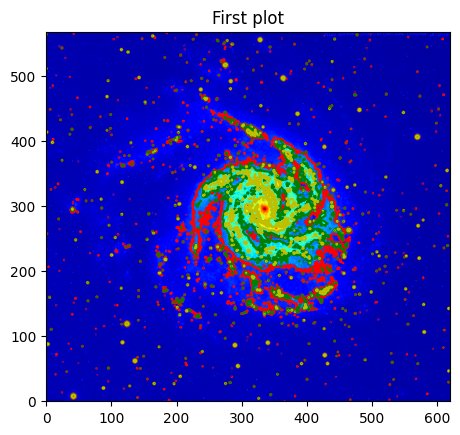

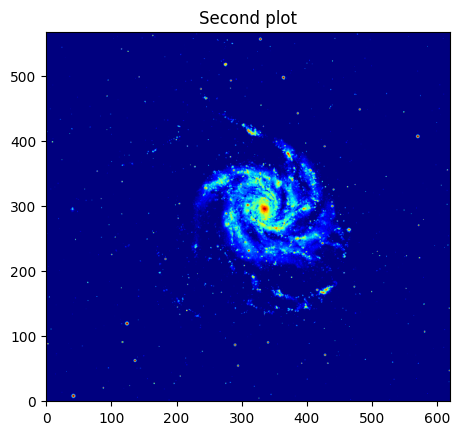

In [5]:
# 5.9
import imageio
import matplotlib.pyplot as plt

m101 = imageio.imread('m101BW.jpg')
plt.title('First plot')
plt.imshow(m101, cmap='jet', origin='lower')
plt.contour(m101, levels=np.percentile(m101, [90,95,99]), colors=['r', 'g', 'y'])
plt.show()

m101 = np.where(m101>np.percentile(m101, [90]), m101, np.percentile(m101, [90]))
plt.title('Second plot')
plt.imshow(m101, cmap='jet', origin='lower')
plt.show()

(40, 50, 70)


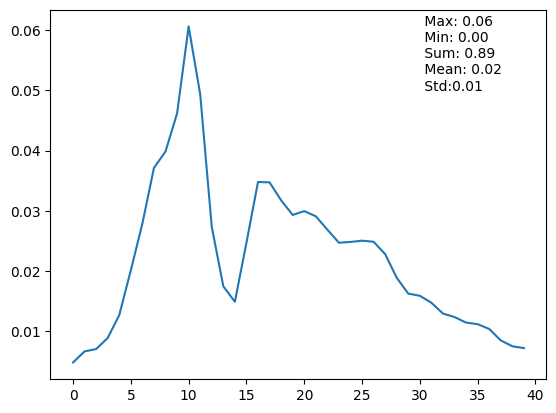

In [50]:
# 5.10
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt', comments="#")
data.shape = (40, 50, 70)
print(data.shape)
z_profile = data[:, int(data.shape[1]/2),int(data.shape[2]/2)] # coordinates are z, y, x
zmax = np.max(z_profile)
zmin = np.min(z_profile)
zsum = np.sum(z_profile)
mean = np.mean(z_profile)
std = np.std(z_profile)

plt.plot(z_profile)
plt.text(x=30, y=0.05,s=f' Max: {zmax:.2f}\n Min: {zmin:.2f}\n Sum: {zsum:.2f}\n Mean: {mean:.2f}\n Std:{std:.2f}')
plt.show()

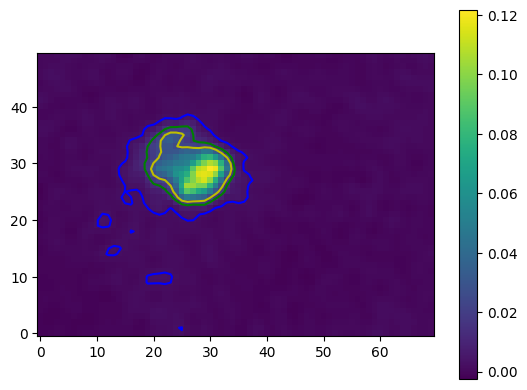

In [45]:
#5.11
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('ngc6946.txt', comments="#")
data.shape = (40, 50, 70)
plane = data[0] # extracting first plane
mean = np.mean(plane)
std = np.std(plane)
plt.imshow(plane, origin='lower')
plt.colorbar()
plt.contour(plane, levels=[mean, mean+std, mean+2*std], colors=['b', 'g', 'y'])
plt.show()

In [10]:
# 5.12
from scipy.constants import c
class Galaxy:    
    """Class for redshift calculation of galaxies"""  
    speed_of_light = c
    caH_0 = 3968.5      # Calcium H line in rest frame
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        v = self.speed_of_light * self.redshift()
        return v
    
galaxy1 = Galaxy('galaxy1', 3969)
print(f'{galaxy1.velocity()} km/s')

37766.7495590829 km/s


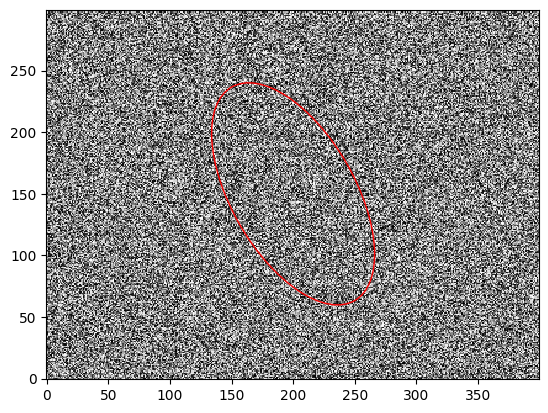

In [3]:
# 5.13
import numpy as np
from matplotlib.pyplot import figure, show
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

class AstroEllipse(Ellipse):
     def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)

Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))
xcenter = 200
ycenter = 150
semimajor = 100
semiminor= 50
theta = 30.0    # degrees, anti clockwise
ell = AstroEllipse(xcenter, ycenter, semimajor, semiminor, theta, fill=False, color='red')
plt.gca().add_patch(ell)
plt.imshow(data, interpolation='none', origin="lower", cmap='gray')
show()